# From a measurement to a calibrated potential

The production path: a measurement as EXFOR reports it, converted to a
`Dataset` in the library's units with its systematics kept as inert
metadata; the reported systematics turned into explicit covariance terms;
the guardrail against a singular covariance; nested sampling of an optical
potential; predictions on any grid; and two side trips, tempering the
likelihood and an inferred model error per data type.

Recipes: 12, 14, 15, 16, 21, 26

In [1]:
from types import SimpleNamespace

import corner
import dill
import dynesty
import emcee
import jitr
import matplotlib.pyplot as plt
import numpy as np
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from scipy import stats

import rxmc as rx
from rxmc import terms as T

## The reaction and the optical model

n + ⁴⁰Ca at 14.1 MeV; a Woods-Saxon potential with volume and surface
absorption and a fixed spin-orbit term.  `ElasticXS` is a `Model` whose
`bind` compiles a jitr solver for the dataset's kinematics, which it reads
from the dataset's `meta`.

In [2]:
reaction = jitr.reactions.ElasticReaction(target=(40, 20), projectile=(1, 0))
E_lab = 14.1
R40 = 40 ** (1 / 3)
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def central(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) - 1j * Wd * (
        -4 * ad
    ) * woods_saxon_prime_safe(r, Rd, ad)


def spin_orbit(r, Vso, Rso, aso):
    return Vso * mso**2 * thomas_safe(r, Rso, aso)


so_args = (6.0, 1.1 * R40, 0.45)
names = ["Vv", "Wv", "Rv", "av", "Wd", "Rd", "ad"]
latex = ["V_v", "W_v", "R_v", "a_v", "W_d", "R_d", "a_d"]
truth = np.array([48.0, 3.5, 1.1 * R40, 0.7, 21.0, 1.2 * R40, 0.5])
prior_mean = np.array([50.0, 3.0, 1.2 * R40, 0.65, 18.0, 1.2 * R40, 0.65])
prior_sd = np.array([7.0, 3.0, 0.2, 0.15, 8.0, 0.2, 0.15])
lower = np.array([0.0, 0.0, 1.0, 0.2, 0.0, 1.0, 0.2])
params = [
    rx.Parameter(n, prior=stats.norm(mu, sd), bounds=(lo, np.inf), latex=lt)
    for n, mu, sd, lo, lt in zip(names, prior_mean, prior_sd, lower, latex)
]
omp = rx.reactions.ElasticXS(
    "dXS/dA", central, spin_orbit, lambda ws, *x: (tuple(x), so_args), params, lmax=10
)

## A measurement, as EXFOR reports it

`exfor_tools` gives a `Distribution` with angles in degrees, cross sections
in a labelled unit, a statistical column, a fractional normalisation
uncertainty and an absolute offset uncertainty.  Here that object is a
`SimpleNamespace` with the same fields, filled with mock data from the true
potential so the calibration can be checked; in production it is the
`exfor_tools` object itself.

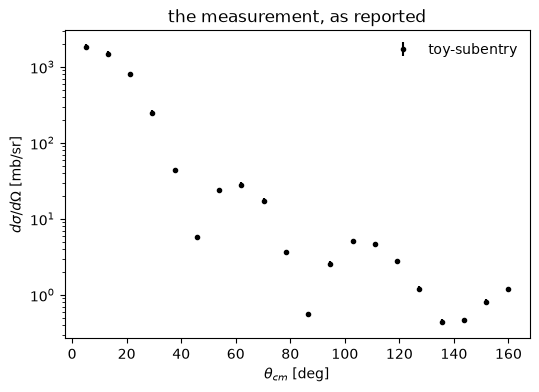

In [3]:
rng = np.random.default_rng(11)
angles_deg = np.linspace(5.0, 160.0, 20)
meta = {"reaction": reaction, "Elab": E_lab}
y_true_b = omp.bind(np.deg2rad(angles_deg), meta)(*truth)  # b/sr
y_true_mb = 1e3 * y_true_b
y_mb = y_true_mb * (1.0 + rng.normal(0.0, 0.08, angles_deg.size))
measurement = SimpleNamespace(
    x=angles_deg,
    y=y_mb,
    Einc=E_lab,
    quantity="dXS/dA",
    y_units="mb/sr",
    statistical_err=0.08 * y_mb,
    systematic_norm_err=0.04,  # fractional
    systematic_offset_err=2.0,  # mb/sr
    subentry="toy-subentry",
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    measurement.x,
    measurement.y,
    measurement.statistical_err,
    fmt="o",
    ms=3,
    color="k",
    label=measurement.subentry,
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$d\sigma/d\Omega$ [mb/sr]",
    yscale="log",
    title="the measurement, as reported",
)
ax.legend(frameon=False)
plt.show()

## `from_measurement`: the unit contract

Angles to radians, cross sections to b/sr; every *dimensionful* error is
converted with the data, the *fractional* normalisation error is left
alone; the kinematics a reaction model needs land in `meta`.  Nothing
correlated is folded into the errors: the systematics wait as attributes.

In [4]:
d = rx.from_measurement(measurement, reaction=reaction)
print(d)
print(
    f"x[:3] = {d.x[:3].round(3)} rad;  y[:3] = {d.y[:3].round(4)} b/sr;  y_err[:3] = {d.y_err[:3].round(4)} b/sr"
)
print(
    f"norm_err = {d.norm_err} (fractional, untouched);  offset_err = {d.offset_err} b/sr (converted)"
)
print("meta keys:", sorted(d.meta))

Dataset('toy-subentry', n=20)
x[:3] = [0.087 0.23  0.372] rad;  y[:3] = [1.8252 1.4888 0.7972] b/sr;  y_err[:3] = [0.146  0.1191 0.0638] b/sr
norm_err = 0.04 (fractional, untouched);  offset_err = 0.002 b/sr (converted)
meta keys: ['Elab', 'eta', 'k', 'quantity', 'reaction', 'subentry']


## Nothing is folded in silently: systematics are explicit terms

`comp.reported_terms()` turns the two reported systematics into covariance
modes: a constant offset mode `ω ω^T` and a normalisation mode
`η² ym_i ym_j` built from the *prediction*.  Ask for them, or leave them
out; there is no default that hides a correlation.

['mode', 'mode'] terms, on ['toy-subentry', 'toy-subentry']


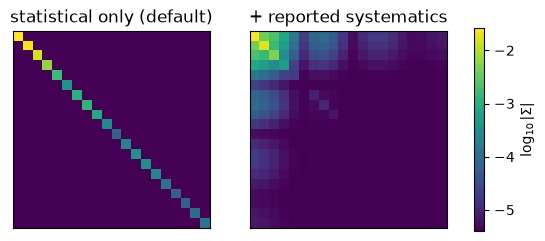

In [5]:
comp = rx.Comparison(d, omp)
reported = comp.reported_terms()
print([t.kind for t in reported], "terms, on", [t.on.data.label for t in reported])
c_stat = rx.Constraint([comp])
c_sys = rx.Constraint([comp], terms=reported)
p_stat, p_sys = rx.Problem([c_stat]), rx.Problem([c_sys])

fig, axes = plt.subplots(1, 2, figsize=(7, 3.3))
for ax, p, title in zip(
    axes, (p_stat, p_sys), ("statistical only (default)", "+ reported systematics")
):
    S = p.constraints[0].matrix(truth)
    im = ax.imshow(np.log10(np.abs(S) + 1e-12), cmap="viridis")
    ax.set(title=title, xticks=[], yticks=[])
fig.colorbar(im, ax=axes, shrink=0.8, label=r"$\log_{10}|\Sigma|$")
plt.show()

## The guardrail: a singular covariance is a named error, not a `LinAlgError`

A subentry without statistical errors contributes zero variance on its
diagonal.  Compiling such a problem fails at construction with a message
that names the comparison and the remedies (recipe 21).

In [6]:
nostat = SimpleNamespace(
    **{
        **vars(measurement),
        "statistical_err": np.zeros_like(y_mb),
        "subentry": "no-statistics",
    }
)
d_nostat = rx.from_measurement(nostat, reaction=reaction)
try:
    rx.Problem([rx.Constraint([rx.Comparison(d_nostat, omp)])])
except ValueError as err:
    print("ValueError:", err)

ValueError: the constraint's covariance is singular on its active points; the diagonal is zero on rows of ['no-statistics']: those comparisons have zero statistical error and no diagonal term covers their points (a block covered only by correlated modes is singular here even when the full covariance is not).  Remedies: comparison.reported_terms(), a noise term, a fixed Term covering those points, or statistical=False with an explicit covariance.


## Calibrate with nested sampling

Optical-model posteriors are correlated and sometimes multimodal, where an
affine-invariant ensemble mixes poorly; dynesty handles them and gives the
evidence for free.  `problem.log_likelihood` and `problem.prior_transform`
are the two callables it needs; the prior transform maps the unit cube
through every parameter's truncated prior.

In [7]:
def nested(problem, seed, nlive=150, dlogz=0.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    res = sampler.results
    print(
        f"log Z = {res.logz[-1]:.2f} +/- {res.logzerr[-1]:.2f}, {int(np.sum(res.ncall))} likelihood calls, efficiency {res.eff:.1f} %"
    )
    return res


res = nested(p_sys, seed=1)
samples = res.samples_equal(rstate=np.random.default_rng(1))
print(f"{samples.shape[0]} equally weighted rows in problem.names order: {p_sys.names}")

log Z = 100.57 +/- 0.44, 48203 likelihood calls, efficiency 4.7 %
2280 equally weighted rows in problem.names order: ['Vv', 'Wv', 'Rv', 'av', 'Wd', 'Rd', 'ad']


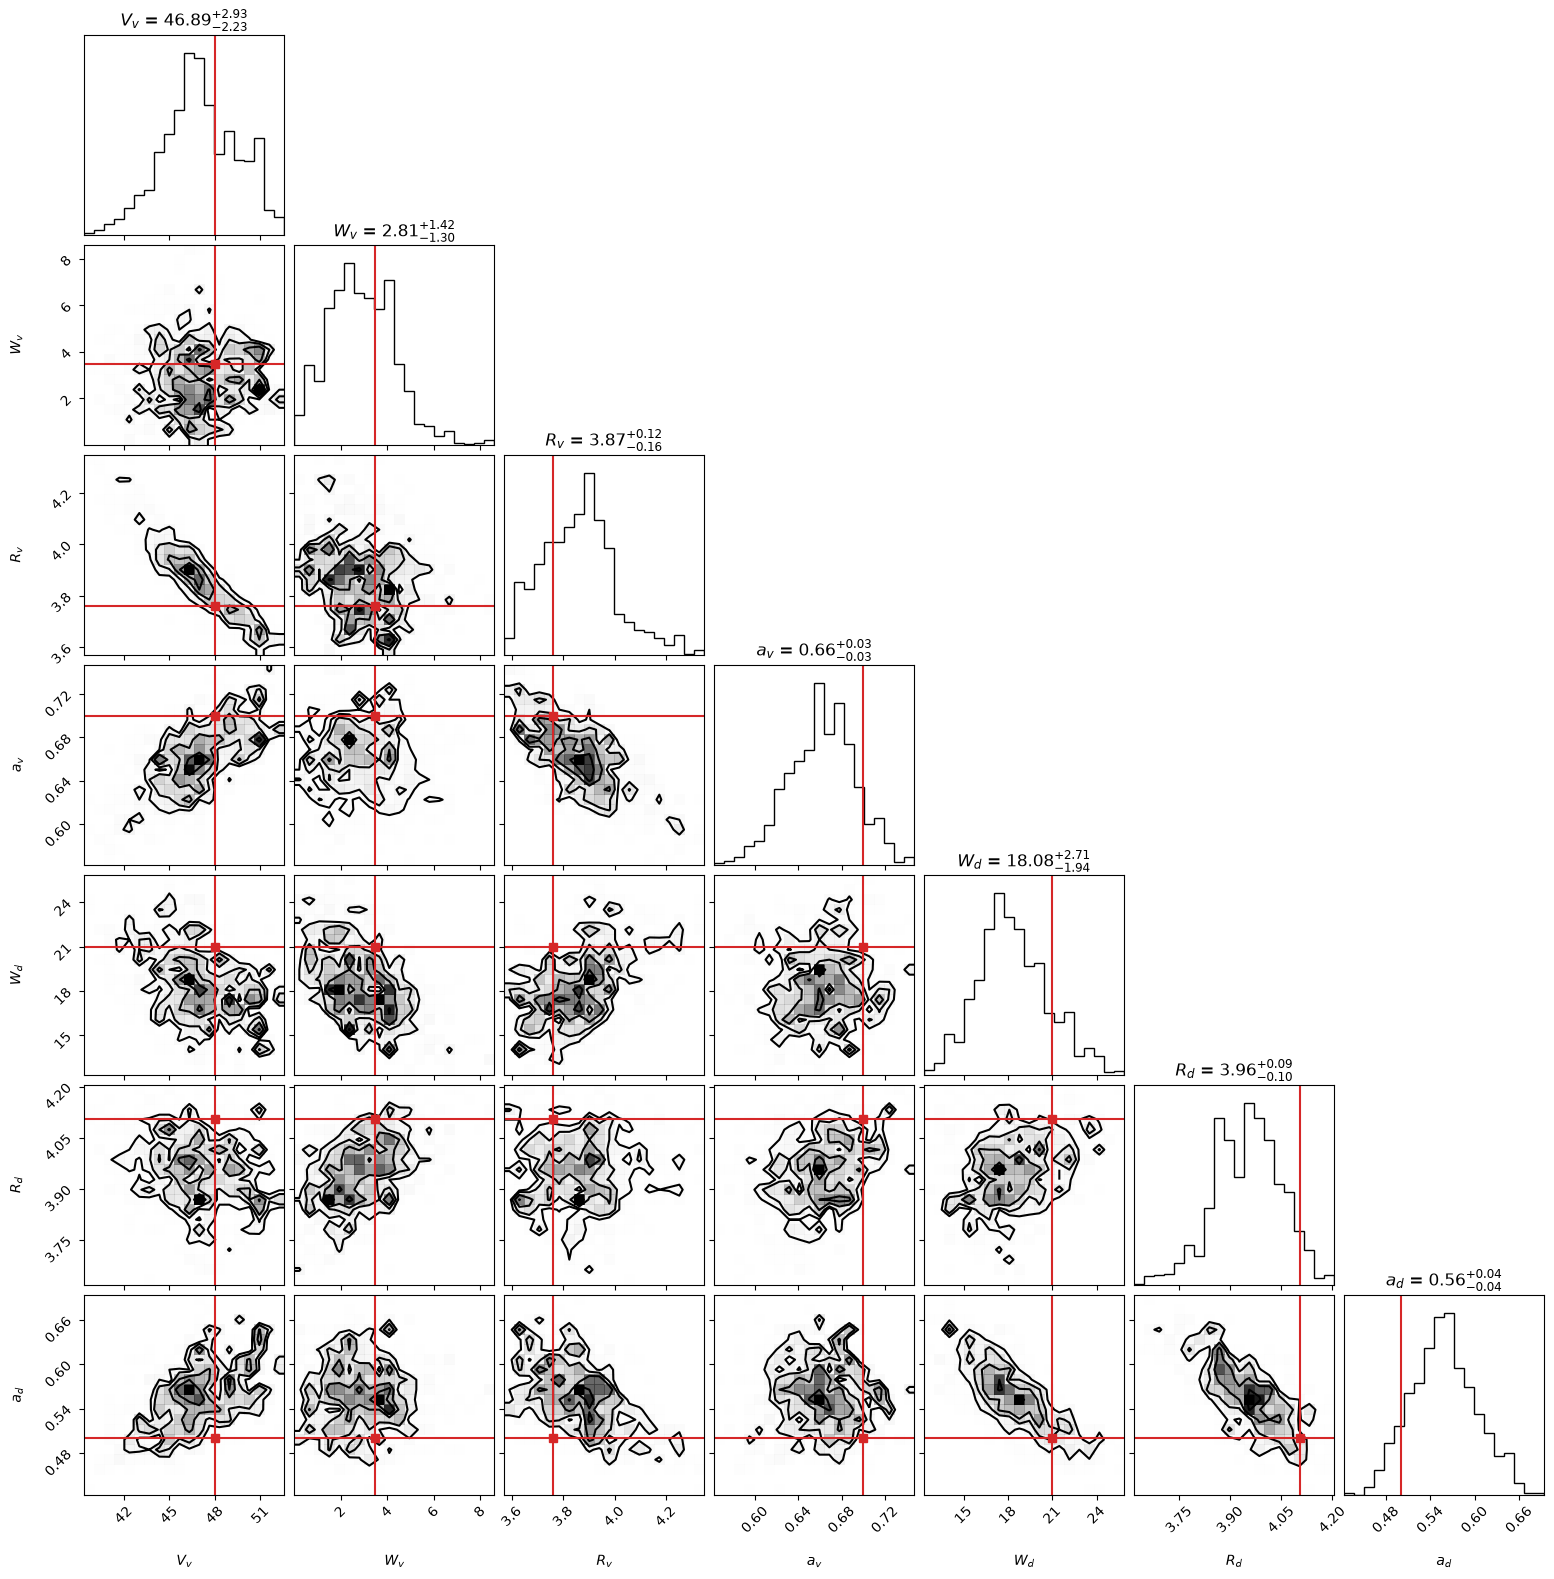

In [8]:
fig = corner.corner(
    samples,
    labels=[f"${lt}$" for lt in latex],
    truths=truth,
    truth_color="C3",
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".2f",
)
plt.show()

## Predictions on any grid (recipe 15)

`omp.bind(x_fine, d.meta)` compiles the same model on a plotting grid; the
angular basis is cached per kinematics, so this costs a few milliseconds per
row.  Columns come from `problem.columns`.

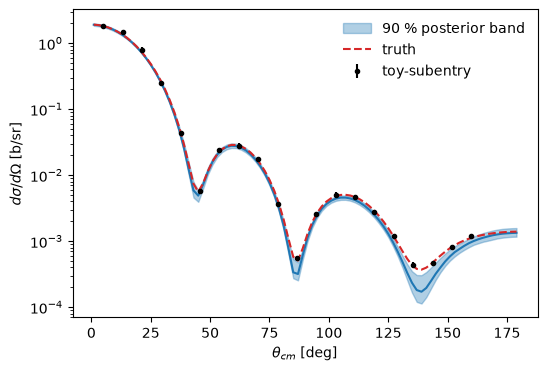

In [9]:
x_fine = np.deg2rad(np.linspace(1.0, 179.0, 90))
on_fine = omp.bind(x_fine, d.meta)
cols = p_sys.columns(omp.params)
curves = np.array([on_fine(*s[cols]) for s in samples[::25]])
lo, mid, hi = rx.predictive.predictive_band(curves, levels=(5, 50, 95))

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(
    np.rad2deg(x_fine), lo, hi, color="C0", alpha=0.35, label="90 % posterior band"
)
ax.plot(np.rad2deg(x_fine), mid, color="C0")
ax.plot(np.rad2deg(x_fine), on_fine(*truth), "--", color="C3", label="truth")
ax.errorbar(np.rad2deg(d.x), d.y, d.y_err, fmt="o", ms=3, color="k", label=d.label)
ax.set(xlabel=r"$\theta_{cm}$ [deg]", ylabel=r"$d\sigma/d\Omega$ [b/sr]", yscale="log")
ax.legend(frameon=False)
plt.show()

## Other drivers (recipe 16)

The same problem runs under emcee from `problem.sample_prior` and
`problem.log_posterior`, and it pickles with `dill` for a driver that
runs in another process.  A short emcee run here only shows the contract;
on optical-model problems expect to need far longer chains than dynesty
needs live points.

In [10]:
sampler = emcee.EnsembleSampler(16, p_sys.ndim, p_sys.log_posterior)
sampler.random_state = np.random.RandomState(2).get_state()
sampler.run_mcmc(p_sys.sample_prior(16, rng=2), 200, progress=False)
print(
    f"emcee: {sampler.get_chain(flat=True).shape[0]} rows, mean acceptance {sampler.acceptance_fraction.mean():.2f}"
)

restored = dill.loads(dill.dumps(p_sys))
print(
    f"dill round trip: ndim {restored.ndim}, names {restored.names[:3]}..., log_posterior(truth) = {restored.log_posterior(truth):.3f} vs {p_sys.log_posterior(truth):.3f}"
)

emcee: 3200 rows, mean acceptance 0.25
dill round trip: ndim 7, names ['Vv', 'Wv', 'Rv']..., log_posterior(truth) = 106.265 vs 106.265


## Tempering the likelihood (recipe 12)

With many points a posterior can collapse tighter than the model deserves.
`Constraint(weight=w)` multiplies that constraint's log-likelihood by `w`
and nothing else; the democratic `k/N` scaling of KDUQ is the case
`w = n_parameters / n_points`.  A 200-point line shows the effect on the
posterior, and the posterior-predictive coverage shows that the *untempered*
fit is not overconfident about the data: the tight posterior is the model's
uncertainty, and the predictive of the data still carries the noise.

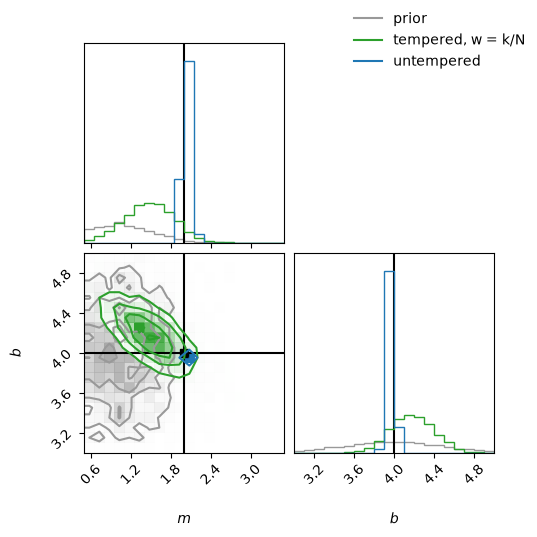

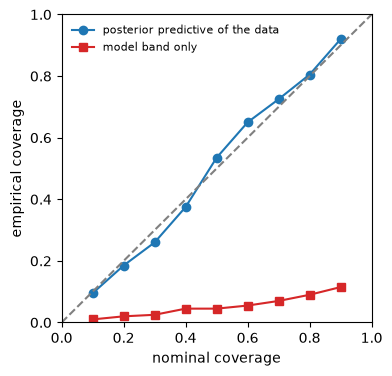

In [11]:
x200 = np.linspace(0.0, 1.0, 200)
y200_true = 2.0 * x200 + 4.0
y200 = y200_true * (1.0 + rng.normal(0.0, 0.05, x200.size))
d200 = rx.Dataset(x200, y200, 0.05 * y200, label="N = 200")
m_, b_ = rx.Parameter("m", prior=stats.norm(1.0, 0.5), latex="m"), rx.Parameter(
    "b", prior=stats.norm(4.0, 0.5), latex="b"
)
line = rx.Model(lambda x, m, b: m * x + b, [m_, b_])
comp200 = rx.Comparison(d200, line)
p_full = rx.Problem([rx.Constraint([comp200])])
p_temp = rx.Problem([rx.Constraint([comp200], weight=2 / 200)])


def fit(problem, seed, n_walkers=24, n_steps=2000):
    s = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    s.random_state = np.random.RandomState(seed).get_state()
    s.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return s.get_chain(discard=n_steps // 3, thin=5, flat=True)


s_full, s_temp = fit(p_full, 3), fit(p_temp, 4)
fig = corner.corner(
    p_full.sample_prior(4000, rng=5),
    color="0.6",
    labels=["$m$", "$b$"],
    truths=[2.0, 4.0],
    truth_color="k",
    plot_datapoints=False,
    range=[(0.5, 3.5), (3.0, 5.0)],
)
corner.corner(
    s_temp, fig=fig, color="C2", plot_datapoints=False, range=[(0.5, 3.5), (3.0, 5.0)]
)
corner.corner(
    s_full, fig=fig, color="C0", plot_datapoints=False, range=[(0.5, 3.5), (3.0, 5.0)]
)
fig.legend(
    handles=[
        plt.Line2D([], [], color="0.6", label="prior"),
        plt.Line2D([], [], color="C2", label="tempered, w = k/N"),
        plt.Line2D([], [], color="C0", label="untempered"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()

draws = rx.diagnostics.predictive_draws(p_full, s_full[::20], n_rep=2, rng=6)
levels = np.linspace(0.1, 0.9, 9)
c200 = p_full.constraints[0]
cov = rx.diagnostics.coverage_curve(draws, c200.y[c200.active], levels)
model_only = rx.diagnostics.predictive_draws(p_full, s_full[::20], model_only=True)
cov_model = rx.diagnostics.coverage_curve(model_only, c200.y[c200.active], levels)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(levels, cov, "o-", label="posterior predictive of the data")
ax.plot(levels, cov_model, "s-", color="C3", label="model band only")
ax.plot([0, 1], [0, 1], "--", color="0.5")
ax.set(xlabel="nominal coverage", ylabel="empirical coverage", xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False, fontsize=8)
plt.show()

## An inferred model error per data type (recipe 26)

KDUQ's treatment of unaccounted-for model error is one `model_error` term
per data type, a diagonal that scales with the prediction and is averaged
over the type's points, with one free fraction per type; its democratic and
federal scalings are the tempering weights above.  With one data type here
the spelling is a single term; a second type would be a second constraint
with its own `delta`.

In [12]:
delta_xs = rx.Parameter(
    "log_delta_dXS", prior=stats.norm(np.log(0.1), 1.0), latex=r"\log\delta_{d\sigma}"
)
c_kduq = rx.Constraint(
    [comp],
    terms=[*reported, T.model_error(delta_xs, averaging=True)],
    weight=len(params) / d.n,
)
p_kduq = rx.Problem([c_kduq])
print("columns:", p_kduq.names)
print(f"weight k/N = {c_kduq.weight:.3f}")

columns: ['Vv', 'Wv', 'Rv', 'av', 'Wd', 'Rd', 'ad', 'log_delta_dXS']
weight k/N = 0.350


## Takeaways

- The unit contract: `from_measurement` converts what is dimensionful and
  leaves fractions alone; the kinematics ride in `meta`.
- Systematics are opt-in terms built from the prediction; nothing correlated
  hides in a default.
- A dataset that contributes zero variance fails at construction with a
  message naming it, not mid-chain.
- dynesty for optical potentials; emcee and dill for whatever else drives
  the same problem.
- Tempering is a weight on a constraint; the predictive check tells you
  whether you needed it.